### Path Finder: What are the potential paths between two nodes?
### This pipeline can be used to get a ranked path between A and B given a set of paths.

In [1]:
import sys
import os
sys.path.append('../TCT/')
import TCT
from TCT import translator_kpinfo
from TCT import node_normalizer
from TCT import name_resolver
from TCT import translator_metakg
from TCT import translator_query
from TCT import TCT_pathfinder

import requests

In [3]:
APInames, metaKG, Translator_KP_info= translator_metakg.load_translator_resources()

All_predicates = list(set(metaKG['Predicate']))
All_categories = list((set(list(set(metaKG['Subject']))+list(set(metaKG['Object'])))))
API_withMetaKG = list(set(metaKG['API']))

    # generate a dictionary of API and its predicates
API_predicates = {}
for api in API_withMetaKG:
    API_predicates[api] = list(set(metaKG[metaKG['API'] == api]['Predicate']))

Skipping server without x-maturity: {'url': '/sipr'}
Skipping server without x-maturity: {'description': 'Local dev', 'url': 'http://127.0.0.1:5001'}


In [4]:
# This is an example of selecting a list of APIs for the neighborhood finder. The user can modify this list to include the APIs they want to use. The APIs in this list are the ones that will be used to find the neighborhood of a given node in the knowledge graph. The user can also modify the list of predicates to use for finding the neighborhood. The predicates in this list are the ones that will be used to find the neighborhood of a given node in the knowledge graph. 
# The user can also modify the list of categories to use for finding the neighborhood. 
# The categories in this list are the ones that will be used to find the neighborhood of a given node in the knowledge graph.
# if selected_APIlist is empty, use all APIs in APInames
selected_APIlist = ['Retriever',
                    'Clinical Trials KP - TRAPI 1.5.0',
                    'Drug Approvals KP - TRAPI 1.5.0',
                    'Genetics Data Provider for NCATS Biomedical Translator Reasoners',
                    'Microbiome KP - TRAPI 1.5.0',
                    'MolePro',
                    'COHD TRAPI',
                    'RTX KG2 - TRAPI 1.5.0',
                    'Text Mined Cooccurrence API',
                    'CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0',
                    'CATRAX Pharmacogenomics KP - TRAPI 1.5.0',
                    ]

# add Automat API to the selected API list if it is not already in the list
for api in APInames:
    if 'Automat' in api and api not in selected_APIlist:
        selected_APIlist.append(api)

selected_APIlist = ['Retriever']

# select a list of APIs to use and a list of predicates to use
if len(selected_APIlist) == 0:
    select_APIs = APInames
else:
    select_APIs = {k: APInames[k] for k in selected_APIlist if k in APInames}

selected_metaKG = metaKG[metaKG['API'].isin(select_APIs.keys())]
#print(select_APIs)
print(selected_metaKG.shape)

All_predicates = list(set(selected_metaKG['Predicate']))
All_categories = list((set(list(set(selected_metaKG['Subject']))+list(set(selected_metaKG['Object'])))))
API_withMetaKG = list(set(selected_metaKG['API']))
API_predicates = {}
for api in API_withMetaKG:
    API_predicates[api] = list(set(selected_metaKG[selected_metaKG['API'] == api]['Predicate']))

(4013, 5)


In [5]:
#name_resolver.lookup('miR-155', only_taxa='NCBITaxon:9606')
subject_name = 'Revumenib'
subject_node = name_resolver.lookup(subject_name).curie
#subject_node = 'CHEBI:39867'
subject_category = name_resolver.lookup(subject_name).types
subject_category = ["biolink:Drug", "biolink:SmallMolecule", "biolink:ChemicalSubstance"]

object_name = 'acute myeloid leukemia'
#object_node = 'MONDO:0016833'
object_node = name_resolver.lookup(object_name, biolink_category='biolink:Disease').curie
object_category = name_resolver.lookup(object_name, biolink_category='biolink:Disease').types
object_category = ["biolink:Disease"]

intermediate_categories = [ 'biolink:Gene']

#name_resolver.lookup('Myelodysplastic syndrome', return_top_response=False, biolink_category='biolink:Disease')

In [6]:
#name_resolver.lookup('miR-155', only_taxa='NCBITaxon:9606')

subject_node = 'CHEBI:39867'
subject_category = name_resolver.lookup(subject_name).types
subject_category = ["biolink:Drug", "biolink:SmallMolecule", "biolink:ChemicalSubstance"]


object_node = 'MONDO:0016833'
#object_node = name_resolver.lookup(object_name, biolink_category='biolink:Disease').curie
object_category = name_resolver.lookup(object_name, biolink_category='biolink:Disease').types
object_category = ["biolink:Disease"]

intermediate_categories = [ 'biolink:Gene']

#name_resolver.lookup('Myelodysplastic syndrome', return_top_response=False, biolink_category='biolink:Disease')

In [ ]:
print(subject_node , object_node)

PUBCHEM.COMPOUND:132212657 MONDO:0018874


CHEBI:39867
MONDO:0016833
Retriever: Success!
NCBIGene:1038: no preferred name
NCBIGene:28638: no preferred name
NCBIGene:28639: no preferred name
NCBIGene:3514: no preferred name
NCBIGene:767558: no preferred name
Number of possible paths:  0


/Users/gqin/Github_repo/Translator_component_toolkit/TCT/TCT.py:1652: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=fontsize)


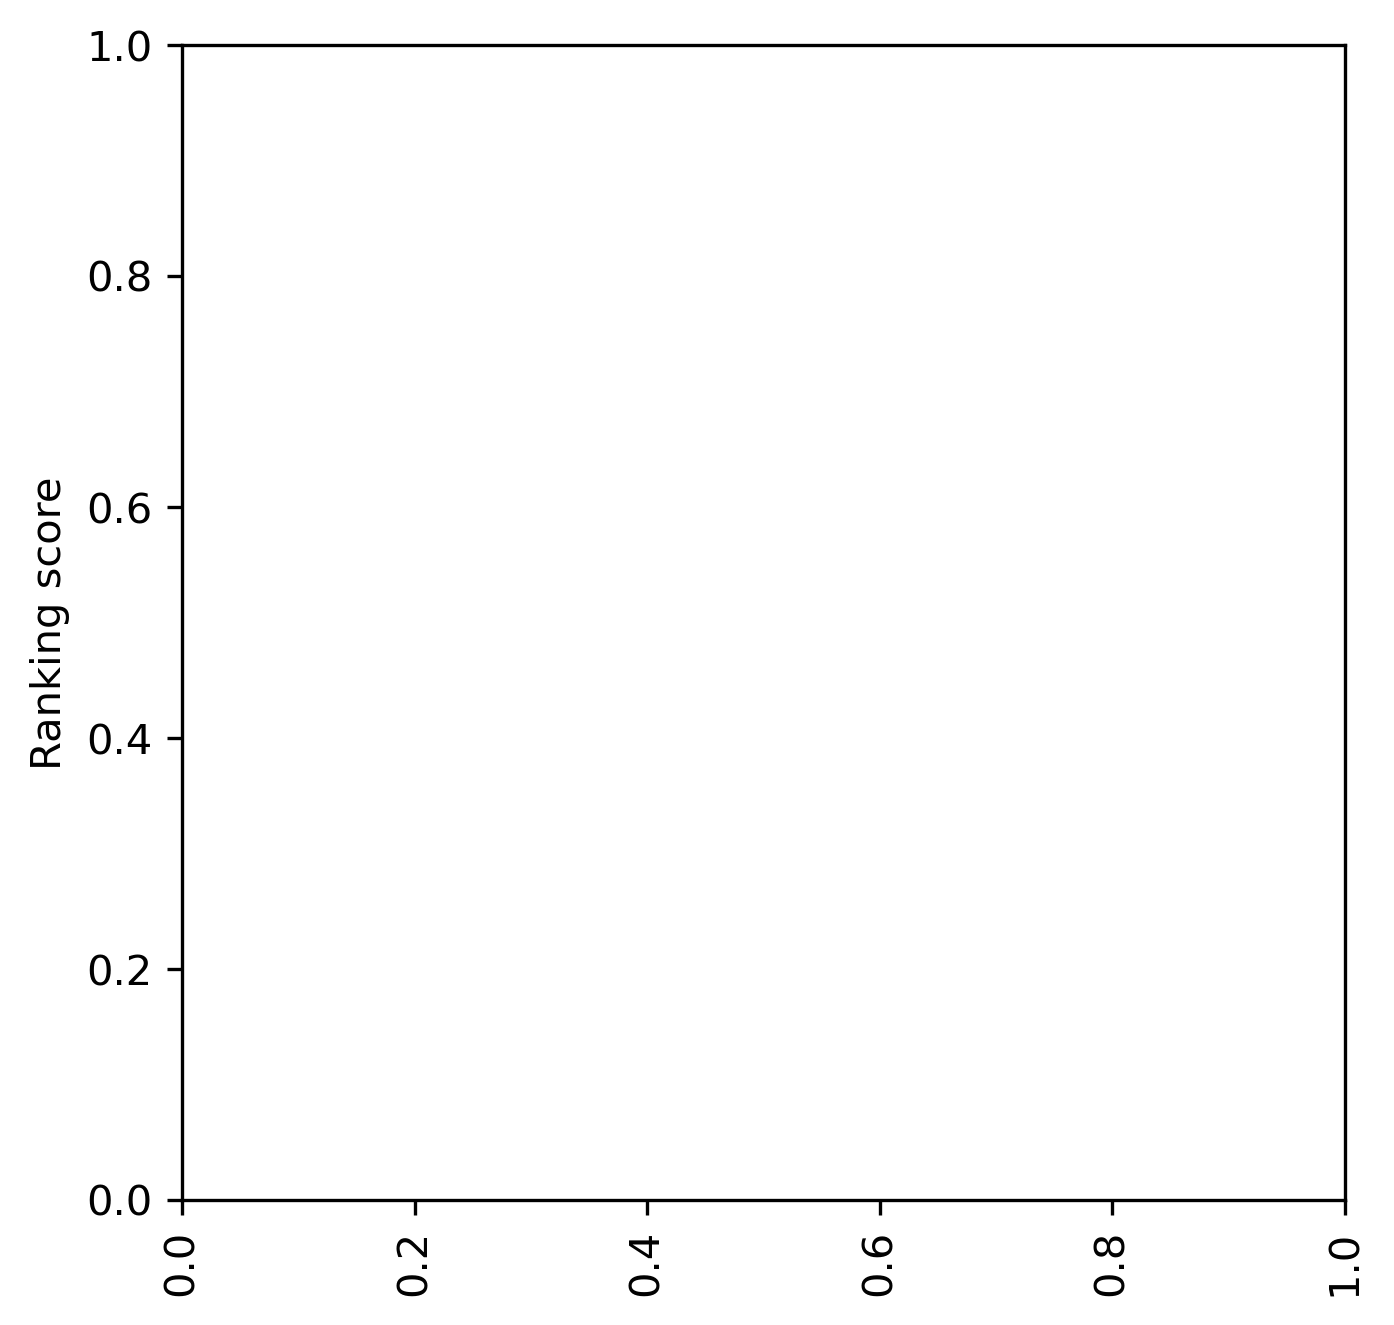

In [7]:
result = TCT.Path_finder(input_node1=subject_node, #IFNG 
                         input_node2= object_node, #COVID-19
                         intermediate_categories=intermediate_categories, 
                         APInames=select_APIs, 
                         metaKG=selected_metaKG, 
                         API_predicates=API_predicates)

In [ ]:
TCT_path_finder_result = TCT_pathfinder.parse_results_for_pathfinder(subject_node, object_node, result1=result['result1'], result2=result['result2'])
# return results path_finder_result to a json file
import json
with open(f'TCT_path_finder_result__{subject_node.replace(":", "_")}__{object_node.replace(":", "_")}_new.json', 'w') as f:
    json.dump(TCT_path_finder_result, f, indent=4)

In [ ]:
TCT_path_finder_result

{'query_graph': {'nodes': {'on': {'categories': None,
    'constraints': [],
    'ids': ['MONDO:0018874'],
    'is_set': False,
    'option_group_id': None,
    'set_id': None,
    'set_interpretation': 'BATCH'},
   'sn': {'categories': None,
    'constraints': [],
    'ids': ['PUBCHEM.COMPOUND:132212657'],
    'is_set': False,
    'option_group_id': None,
    'set_id': None,
    'set_interpretation': 'BATCH'}},
  'paths': {'p0': {'constraints': None,
    'object': 'on',
    'predicates': None,
    'subject': 'sn'}}},
 'knowledge_graph': {'nodes': {'NCBIGene:4221': {'name': 'MEN1',
    'categories': ['biolink:Gene',
     'biolink:GeneOrGeneProduct',
     'biolink:GenomicEntity',
     'biolink:ChemicalEntityOrGeneOrGeneProduct',
     'biolink:PhysicalEssence',
     'biolink:OntologyClass',
     'biolink:BiologicalEntity',
     'biolink:ThingWithTaxon',
     'biolink:NamedThing',
     'biolink:PhysicalEssenceOrOccurrent',
     'biolink:MacromolecularMachineMixin',
     'biolink:Protein',

In [ ]:
# visulize the paths in visulize_path_finder_results.html

In [ ]:
intermediate_categories = ['biolink:Protein']

In [ ]:
intermediate_categories

['biolink:Gene']

In [ ]:
# query arax pathfinder with constraints and write response to a json file
import time
start_time = time.time()
result_arax = TCT_pathfinder.query_arax_pathfinder_with_constraints(subject_node, 
                                                                    subject_category,
                                                                    object_node, 
                                                                    object_category, 
                                                                    constraints=intermediate_categories                                                                
                                                                    )
end_time = time.time()
arax_execution_time = end_time - start_time
if result_arax.json()['message'].get('auxiliary_graphs') is not None:
    Number_of_paths_ARAX_constrained = len(result_arax.json()['message']['auxiliary_graphs'])
else:    
    Number_of_paths_ARAX_constrained = 0
print(f"ARAX execution time with constraints: {arax_execution_time} seconds")
print(f"Number of paths ARAX with constraints: {Number_of_paths_ARAX_constrained}")
import json
with open('arax_pathfinder_response_'+subject_name.replace(":", "_")+'_'+object_name.replace(":", "_")+'with_constraints.json', 'w') as f:
    json.dump(result_arax.json()['message'], f, indent=4)

ARAX execution time with constraints: 30.241100072860718 seconds
Number of paths ARAX with constraints: 500


In [ ]:
# run aragorn pathfinder without constraints and write response to a json file
import time
start_time = time.time()

# Note: for ARAGORN or ARAX pathfinder pipeline, it is only allowed to have only one intermediate category in the constraints list. If there are multiple intermediate categories, the query will return an error. Therefore, we will only use one intermediate category in  the constraints list. 

aragorn_response = TCT_pathfinder.query_aragorn_pathfinder_with_constraints(subject_node, 
                                                           subject_category, 
                                                           object_node, 
                                                           object_category, 
                                                           constraints=intermediate_categories)
# write response to a json file
import json
if 'message' in aragorn_response.json():
    with open('aragorn_pathfinder_response_'+subject_name.replace(":", "_")+'_'+object_name.replace(":", "_")+'constrained.json', 'w') as f:
        json.dump(aragorn_response.json()['message'], f, indent=4)
end_time = time.time()
aragorn_execution_time = end_time - start_time
if 'auxiliary_graphs' in aragorn_response.json()['message']:
    Number_of_paths_aragorn = len(aragorn_response.json()['message']['auxiliary_graphs'])
else:
    Number_of_paths_aragorn = 0
    print("No paths found in Aragorn response.")
print(f"Aragorn execution time: {aragorn_execution_time} seconds")
print(f"Number of paths Aragorn: {Number_of_paths_aragorn}")

Aragorn execution time: 1.8005821704864502 seconds
Number of paths Aragorn: 0


In [ ]:
# run aragorn pathfinder without constraints and write response to a json file
start_time = time.time()
aragorn_response = TCT_pathfinder.query_aragorn_pathfinder(subject_node, 
                                                           subject_category, 
                                                           object_node, 
                                                           object_category)
# write response to a json file
import json
if 'message' in aragorn_response.json():
    with open('aragorn_pathfinder_response_'+subject_name.replace(":", "_")+'_'+object_name.replace(":", "_")+'.json', 'w') as f:
        json.dump(aragorn_response.json()['message'], f, indent=4)
end_time = time.time()
aragorn_execution_time = end_time - start_time
if aragorn_response.json()['message'].get('auxiliary_graphs') is not None:
    Number_of_paths_aragorn = len(aragorn_response.json()['message']['auxiliary_graphs'])
else:
    Number_of_paths_aragorn = 0
    print("No paths found in Aragorn response.")
print(f"Aragorn execution time: {aragorn_execution_time} seconds")
print(f"Number of paths Aragorn: {Number_of_paths_aragorn}")

Aragorn execution time: 4.127230167388916 seconds
Number of paths Aragorn: 29


In [ ]:
arax_response = TCT_pathfinder.query_arax_pathfinder(subject_node, 'biolink:SmallMolecule', object_node, 'biolink:Disease')
# write response to a json file
import json
with open('arax_pathfinder_response_'+subject_node.replace(":", "_")+'_'+object_node.replace(":", "_")+'.json', 'w') as f:
    json.dump(arax_response.json()['message'], f, indent=4)
arax_execution_time = end_time - start_time
if arax_response.json()['message'].get('auxiliary_graphs') is not None:
    Number_of_paths_ARAX = len(arax_response.json()['message']['auxiliary_graphs'])
else:    
    Number_of_paths_ARAX = 0
print(f"ARAX execution time: {arax_execution_time} seconds")
print(f"Number of paths ARAX: {Number_of_paths_ARAX}")


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

# link to the UI
https://ui.ci.transltr.io/

# link to TCT results visulization
./visulize_path_finder_results.html
